# Stateful Strategy Patterns

**Docker image**: `ml4t`

This notebook shows when a sequential backtest is the clearest representation
of a trading strategy.
In this chapter, "vectorized" means expressing the strategy as precomputed
aligned arrays such as signals, ranks, target weights, or cost estimates.
"Sequential" means evaluating the strategy bar by bar while carrying mutable
state such as positions, realized P&L, equity, or pending orders.

Many strategies can be written either way. If the full trading protocol can be
defined in advance, the array-based approach is attractive because it is fast
and broadcasts naturally across parameter grids, at the cost of materializing
larger intermediate objects in memory. A sequential engine earns its keep when
later decisions depend on earlier execution outcomes or on broker state that
is awkward to encode as a fixed matrix.

That difference is also one of description. Trading itself has a loop-like
character: observe the market, update state, decide, execute, and repeat.
Array-based backtests compress that loop into aligned matrices. This buys speed
and broad parameter sweeps, but it also makes the logic more abstract and can
make mistakes harder to spot when timing, fills, or state transitions are not
written down explicitly. Sequential backtests stay closer to the way the
strategy would be described to a trader or implemented in a live system.

## The Core Distinction

Array-based: compute `signals[t]`, `weights[t]`, or `orders[t]` from observed
data and predetermined rules, then apply the portfolio update.

Sequential: update `action[t]` from observed data plus evolving state, for
example `action[t] = g(data[0:t], positions[t-1], fills[0:t-1], equity[t-1])`.

This notebook uses `ml4t-backtest` for the sequential implementation. The
examples are meant to show when explicit state is useful, not to claim that
another framework can never reproduce the same protocol.

## Three Patterns Demonstrated

| Pattern | Why sequential state is a natural fit |
|---------|---------------------------------------|
| **Adaptive Kelly Sizing** | Position size depends on realized trade outcomes, so sizing becomes a recursive update rather than a fixed weight matrix |
| **Pairs Trading** | The two legs share cash, margin, and fill coordination, which is easier to reason about when state is explicit |
| **Drawdown Circuit Breaker** | Exposure changes with the realized equity path, so future actions depend on prior portfolio evolution |

**Learning Objectives:**
1. Distinguish array-based backtests from sequential stateful simulation.
2. Implement strategies whose rules depend on prior fills, positions, or equity.
3. Judge when the extra flexibility of sequential simulation is worth the cost.

**Book Reference:** Chapter 16, Section 16.3 — when event-driven simulation is
the clearest representation of a trading strategy.

**Prerequisites:** [`04_single_asset_ml4t_backtest`](04_single_asset_ml4t_backtest.ipynb) for the
`ml4t-backtest` API (Engine, Strategy, DataFeed).

**Library Reference:** See the [Stateful Strategies](https://github.com/stefan-jansen/ml4t-backtest/docs/user-guide/stateful-strategies.md)
guide for all five pattern categories and the broker state API.

## Setup

In [1]:
"""Stateful Strategy Patterns — sequential backtesting with trailing stops, pairs trading, and circuit breakers."""

import warnings

warnings.filterwarnings("ignore")

In [2]:
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import ShareType
from plotly.subplots import make_subplots

import utils  # noqa: F401
from data import load_etfs
from utils.reproducibility import set_global_seeds

In [3]:
# Production defaults — Papermill injects overrides after this cell
N_BARS = 500
SEED = 42

In [4]:
set_global_seeds(SEED)

## Data: Real ETF Bars from `load_etfs`

Each pattern uses a real ETF window chosen for the stateful behavior it
exercises. The data path is the same as the sibling Ch16 notebooks
(`load_etfs` returns daily OHLCV for the publication universe). Three
windows are loaded on demand inside each section below.

In [5]:
def _load_single_window(symbol: str, start: str, n_bars: int) -> pl.DataFrame:
    """Load the first ``n_bars`` daily OHLCV bars for ``symbol`` from ``start``.

    Returns a stacked Polars DataFrame with the timestamp/symbol/OHLCV schema
    expected by ``DataFeed`` (datetime-typed timestamp for engine compatibility).
    """
    df = (
        load_etfs()
        .filter((pl.col("symbol") == symbol) & (pl.col("timestamp") >= pl.lit(start).str.to_date()))
        .sort("timestamp")
        .head(n_bars)
        .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    )
    if df.height < n_bars:
        raise ValueError(
            f"load_etfs returned {df.height} bars for {symbol} from {start}; need {n_bars}"
        )
    return df.select(["timestamp", "symbol", "open", "high", "low", "close", "volume"])


def _load_pair_window(symbol_a: str, symbol_b: str, start: str, n_bars: int) -> pl.DataFrame:
    """Load aligned daily OHLCV for two symbols, restricted to common timestamps.

    Both legs are truncated to the first ``n_bars`` shared trading days.
    """
    raw = (
        load_etfs()
        .filter(
            pl.col("symbol").is_in([symbol_a, symbol_b])
            & (pl.col("timestamp") >= pl.lit(start).str.to_date())
        )
        .sort(["timestamp", "symbol"])
        .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    )
    # Inner-join the two legs on timestamp so the panel is bar-aligned.
    counts = raw.group_by("timestamp").len()
    shared = counts.filter(pl.col("len") == 2)["timestamp"]
    panel = (
        raw.filter(pl.col("timestamp").is_in(shared))
        .sort(["timestamp", "symbol"])
        .with_columns(pl.col("timestamp"))
    )
    # First n_bars timestamps with both legs present.
    shared_sorted = sorted(shared.to_list())[:n_bars]
    if len(shared_sorted) < n_bars:
        raise ValueError(
            f"Only {len(shared_sorted)} aligned bars for {symbol_a}/{symbol_b} "
            f"from {start}; need {n_bars}"
        )
    return panel.filter(pl.col("timestamp").is_in(shared_sorted)).select(
        ["timestamp", "symbol", "open", "high", "low", "close", "volume"]
    )

### Signal Generator

Generate momentum, random, or alternating signals for the loaded prices.

In [6]:
def make_signals(
    prices: pl.DataFrame,
    signal_fn: str = "momentum",
    lookback: int = 20,
) -> pl.DataFrame:
    """Generate signal column for the given prices.

    signal_fn options:
        'momentum': rolling return over lookback
        'random': uniform random in [-1, 1]
        'alternating': alternates between +1 and -1 every lookback bars
    """
    parts = []
    for asset in prices["symbol"].unique().to_list():
        asset_df = prices.filter(pl.col("symbol") == asset).sort("timestamp")
        close = asset_df["close"]

        if signal_fn == "momentum":
            signal = (close / close.shift(lookback) - 1).fill_null(0.0)
        elif signal_fn == "random":
            asset_seed = sum(ord(c) for c in asset)
            signal = pl.Series(np.random.default_rng(asset_seed).uniform(-1, 1, len(close)))
        elif signal_fn == "alternating":
            vals = np.zeros(len(close))
            for i in range(len(close)):
                vals[i] = 1.0 if (i // lookback) % 2 == 0 else -1.0
            signal = pl.Series(vals)
        else:
            raise ValueError(f"Unknown signal_fn: {signal_fn}")

        parts.append(
            pl.DataFrame(
                {
                    "timestamp": asset_df["timestamp"],
                    "symbol": asset_df["symbol"],
                    "signal": signal,
                }
            )
        )

    return pl.concat(parts).sort(["timestamp", "symbol"])

## Pattern 1: Adaptive Kelly Sizing (Feedback Loop)

**The idea**: Position size at each entry adapts based on the realized win rate
and payoff ratio from prior trades. The feedback loop:

```
position_size → P&L → Kelly_fraction → next_position_size
```

**Why a fixed matrix is awkward**: The Kelly fraction at bar N depends on trade
outcomes from bars 0..N-1, but those outcomes were themselves shaped by earlier
Kelly sizes. The rule is naturally recursive. You can code that recursion, but
not as a single precomputed signal matrix.

### Kelly Formula

The Kelly criterion determines the optimal fraction of capital to risk:

$$f^* = W - \frac{1 - W}{R}$$

where $W$ = win rate and $R$ = average win / average loss.
We use **half-Kelly** ($0.5 \times f^*$) for safety.

In [7]:
class AdaptiveKellySizingStrategy(Strategy):
    """Position size adapts based on realized win rate and payoff ratio."""

    def __init__(
        self,
        signal_column: str = "signal",
        entry_threshold: float = 0.01,
        exit_threshold: float = -0.01,
        base_size: float = 0.10,
        min_size: float = 0.02,
        max_size: float = 0.25,
        kelly_fraction: float = 0.5,
        min_trades: int = 5,
    ):
        self.signal_column = signal_column
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.base_size = base_size
        self.min_size = min_size
        self.max_size = max_size
        self.kelly_fraction = kelly_fraction
        self.min_trades = min_trades
        # Track state for analysis
        self.size_history: list[float] = []
        self.trade_outcomes: list[float] = []

    def _kelly_size(self, broker, asset):
        """Compute position size as fraction of equity using Kelly criterion."""
        stats = broker.get_asset_stats(asset)
        if stats.total_trades < self.min_trades:
            return self.base_size

        w = stats.recent_win_rate
        wins = [p for p in stats.recent_pnls if p > 0]
        losses = [p for p in stats.recent_pnls if p <= 0]
        if not wins or not losses:
            return self.base_size

        avg_win = sum(wins) / len(wins)
        avg_loss = abs(sum(losses) / len(losses))
        if avg_loss == 0:
            return self.max_size

        r = avg_win / avg_loss
        f_star = w - (1 - w) / r
        f_star = max(0.0, f_star) * self.kelly_fraction
        return max(self.min_size, min(self.max_size, f_star))

    def on_data(self, timestamp, data, context, broker):
        for asset, bar in data.items():
            signals = bar.get("signals", {})
            signal = signals.get(self.signal_column, 0) if signals else 0
            if signal is None:
                signal = 0

            price = bar.get("close", 0)
            if price <= 0:
                continue

            position = broker.get_position(asset)

            if position is None and signal > self.entry_threshold:
                size_frac = self._kelly_size(broker, asset)
                self.size_history.append(size_frac)
                equity = broker.get_account_value()
                shares = (equity * size_frac) / price
                if shares > 0:
                    broker.submit_order(asset, shares)
            elif position is not None and signal < self.exit_threshold:
                broker.close_position(asset)

### Run Kelly Strategy

We use QQQ daily bars from 2018-01 through 2019-12 (500 trading days). The
window covers the Q4 2018 correction and the subsequent 2019 recovery, so
the realized win rate and payoff ratio shift enough to exercise the Kelly
feedback loop.

In [8]:
prices = _load_single_window(symbol="QQQ", start="2018-01-01", n_bars=N_BARS)
signals = make_signals(prices, signal_fn="momentum", lookback=20)
KELLY_SYMBOL = "QQQ"

config = BacktestConfig(
    initial_cash=100_000,
    commission_rate=0.001,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
)

# Kelly strategy
kelly_strategy = AdaptiveKellySizingStrategy(
    entry_threshold=0.02,
    exit_threshold=-0.01,
    base_size=0.10,
    min_size=0.02,
    max_size=0.25,
    kelly_fraction=0.5,
    min_trades=3,
)

feed = DataFeed(prices_df=prices, signals_df=signals)
engine = Engine(feed=feed, strategy=kelly_strategy, config=config)
kelly_result = engine.run()

**Adaptive Kelly sizing — backtest summary:**

In [9]:
m = kelly_result.metrics
pl.DataFrame(
    {
        "metric": [
            "Total return (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Total trades",
            "Win rate (%)",
        ],
        "value": [
            float(m["total_return_pct"]),
            float(m["sharpe"]),
            float(m["max_drawdown_pct"]),
            float(m["num_trades"]),
            float(m.get("win_rate", 0) * 100),
        ],
    }
)

metric,value
str,f64
"""Total return (%)""",-0.572452
"""Sharpe ratio""",-0.43189
"""Max drawdown (%)""",1.527904
"""Total trades""",10.0
"""Win rate (%)""",20.0


The Kelly criterion starts at the base size (10%) and adapts as the realized
win rate and payoff ratio are incorporated. The Q4 2018 correction inside this
QQQ window pushes the recent win rate down, which the half-Kelly rule
translates into smaller subsequent sizes; the 2019 recovery pulls the multiplier
back toward the base — the feedback loop is the lesson, not the absolute return.

### Visualize Position Size Adaptation

The key observable: position sizes change over time as the strategy learns
from its own trade outcomes.

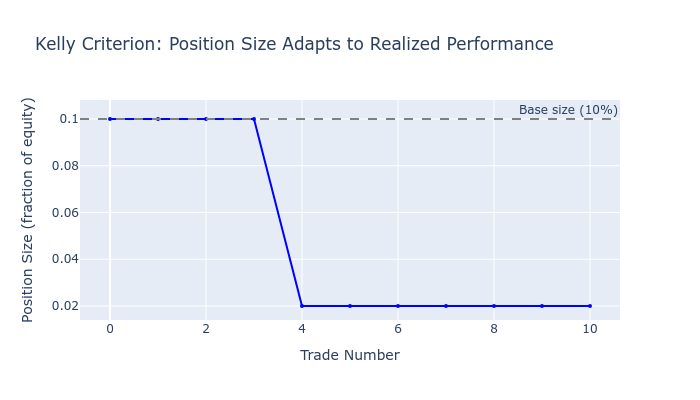


Position sizes ranged from 0.020 to 0.100
Base size: 0.100 | Mean actual: 0.049


In [10]:
if kelly_strategy.size_history:
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            y=kelly_strategy.size_history,
            mode="lines+markers",
            name="Position Size (fraction)",
            line=dict(color="blue"),
            marker=dict(size=4),
        )
    )
    fig.add_hline(y=0.10, line_dash="dash", line_color="gray", annotation_text="Base size (10%)")
    fig.update_layout(
        title="Kelly Criterion: Position Size Adapts to Realized Performance",
        xaxis_title="Trade Number",
        yaxis_title="Position Size (fraction of equity)",
        height=400,
    )
    fig.show()

    print(
        f"\nPosition sizes ranged from {min(kelly_strategy.size_history):.3f} "
        f"to {max(kelly_strategy.size_history):.3f}"
    )
    print(f"Base size: 0.100 | Mean actual: {np.mean(kelly_strategy.size_history):.3f}")

### Compare to Fixed-Size Baseline

To see the impact of adaptive sizing, run the same signals with a fixed 10% position.

In [11]:
class FixedSizeStrategy(Strategy):
    """Baseline: always uses fixed position size (no adaptation)."""

    def __init__(self, size=0.10, entry_threshold=0.02, exit_threshold=-0.01):
        self.size = size
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold

    def on_data(self, timestamp, data, context, broker):
        for asset, bar in data.items():
            signals = bar.get("signals", {})
            signal = signals.get("signal", 0) if signals else 0
            if signal is None:
                signal = 0
            price = bar.get("close", 0)
            if price <= 0:
                continue

            position = broker.get_position(asset)
            if position is None and signal > self.entry_threshold:
                shares = (broker.get_account_value() * self.size) / price
                if shares > 0:
                    broker.submit_order(asset, shares)
            elif position is not None and signal < self.exit_threshold:
                broker.close_position(asset)


fixed_strategy = FixedSizeStrategy(size=0.10, entry_threshold=0.02, exit_threshold=-0.01)
feed_fixed = DataFeed(prices_df=prices, signals_df=signals)
engine_fixed = Engine(feed=feed_fixed, strategy=fixed_strategy, config=config)
fixed_result = engine_fixed.run()

**Adaptive Kelly vs fixed-size baseline** — same signals, different sizing rule:

In [12]:
fm = fixed_result.metrics
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "adaptive_kelly": [
            float(m["total_return_pct"]),
            float(m["sharpe"]),
            float(m["max_drawdown_pct"]),
            float(m["num_trades"]),
        ],
        "fixed_10pct": [
            float(fm["total_return_pct"]),
            float(fm["sharpe"]),
            float(fm["max_drawdown_pct"]),
            float(fm["num_trades"]),
        ],
    }
)

metric,adaptive_kelly,fixed_10pct
str,f64,f64
"""Total return (%)""",-0.572452,0.651028
"""Sharpe ratio""",-0.43189,0.29476
"""Max drawdown (%)""",1.527904,1.527904
"""Total trades""",10.0,10.0


**Key observation**: Both strategies see the same entry and exit signals, but
Kelly updates exposure from realized outcomes. After a losing streak it reduces
size; after a winning streak it can rebuild size. That recursive state update
is straightforward in a sequential engine and awkward to express as a static
array calculation.

## Pattern 2: Pairs Trading (Contingent Multi-Leg Execution)

**The idea**: Trade the spread between two correlated assets, but stage the pair
entry. The strategy opens the lead leg first, waits to observe the realized fill,
and then sizes the hedge from the actual filled notional rather than from an
idealized target weight.

**Why a fixed matrix is awkward**: The spread signal is easy to precompute, but
the trade management is contingent. The hedge size depends on the realized lead
leg quantity and entry price, both of which are outputs of the simulation. If
the hedge cannot be established quickly, the lead leg should be unwound rather
than treated as a valid standalone trade.

### Spread Trading Logic

1. Compute rolling z-score of the price ratio B/A
2. If z-score > 2.0: open the long A lead leg, then hedge with short B
3. If z-score < -2.0: open the long B lead leg, then hedge with short A
4. Size the hedge from the realized lead-leg fill, not the intended target
5. If |z-score| < 0.5 or the hedge cannot be completed, exit the pair

In [13]:
class PairsTradingStrategy(Strategy):
    """Trade a spread using staged, stateful pair entry."""

    def __init__(
        self,
        asset_a: str = "XLF",
        asset_b: str = "KRE",
        lookback: int = 20,
        entry_zscore: float = 2.0,
        exit_zscore: float = 0.5,
        position_size: float = 0.10,
    ):
        self.asset_a = asset_a
        self.asset_b = asset_b
        self.lookback = lookback
        self.entry_zscore = entry_zscore
        self.exit_zscore = exit_zscore
        self.position_size = position_size
        # State
        self.price_history_a: list[float] = []
        self.price_history_b: list[float] = []
        self.pair_status: str = "flat"
        self.lead_asset: str | None = None
        self.hedge_asset: str | None = None
        self.pending_bars: int = 0
        self.failed_hedges: int = 0
        # Track for analysis
        self.zscore_history: list[float] = []
        self.status_history: list[str] = []

    def _reset_pair_state(self) -> None:
        self.pair_status = "flat"
        self.lead_asset = None
        self.hedge_asset = None
        self.pending_bars = 0

    def _start_pair(self, long_asset: str, short_asset: str, long_price: float, broker) -> None:
        equity = broker.get_account_value()
        shares = (equity * self.position_size) / long_price
        if shares <= 0:
            return
        broker.submit_order(long_asset, shares)
        self.lead_asset = long_asset
        self.hedge_asset = short_asset
        self.pair_status = "waiting_for_lead_fill"
        self.pending_bars = 0

    def _submit_hedge(self, short_price: float, broker) -> None:
        if self.lead_asset is None or self.hedge_asset is None:
            return

        lead_position = broker.get_position(self.lead_asset)
        if lead_position is None or lead_position.quantity <= 0:
            return

        realized_notional = abs(lead_position.quantity) * lead_position.entry_price
        hedge_shares = realized_notional / short_price
        if hedge_shares <= 0:
            return

        broker.submit_order(self.hedge_asset, -hedge_shares)
        self.pair_status = "waiting_for_hedge_fill"
        self.pending_bars = 0

    def _compute_zscore(self):
        if len(self.price_history_a) < self.lookback:
            return None
        ratios = [
            b / a
            for a, b in zip(
                self.price_history_a[-self.lookback :],
                self.price_history_b[-self.lookback :],
                strict=False,
            )
            if a > 0
        ]
        if len(ratios) < 2:
            return None
        mean_r = sum(ratios) / len(ratios)
        var_r = sum((r - mean_r) ** 2 for r in ratios) / (len(ratios) - 1)
        std_r = var_r**0.5
        if std_r == 0:
            return None
        current_ratio = self.price_history_b[-1] / self.price_history_a[-1]
        return (current_ratio - mean_r) / std_r

    def on_data(self, timestamp, data, context, broker):
        bar_a = data.get(self.asset_a)
        bar_b = data.get(self.asset_b)
        if bar_a is None or bar_b is None:
            return

        price_a = bar_a.get("close", 0)
        price_b = bar_b.get("close", 0)
        if price_a <= 0 or price_b <= 0:
            return

        self.price_history_a.append(price_a)
        self.price_history_b.append(price_b)

        z = self._compute_zscore()
        if z is None:
            self.zscore_history.append(0.0)
            self.status_history.append(self.pair_status)
            return

        self.zscore_history.append(z)
        lead_position = broker.get_position(self.lead_asset) if self.lead_asset else None
        hedge_position = broker.get_position(self.hedge_asset) if self.hedge_asset else None

        if self.pair_status == "waiting_for_lead_fill":
            if lead_position is not None and lead_position.quantity > 0:
                hedge_price = price_b if self.hedge_asset == self.asset_b else price_a
                self._submit_hedge(hedge_price, broker)
            else:
                self.pending_bars += 1
                if self.pending_bars > 1:
                    self._reset_pair_state()
            self.status_history.append(self.pair_status)
            return

        if self.pair_status == "waiting_for_hedge_fill":
            if (
                lead_position is not None
                and hedge_position is not None
                and hedge_position.quantity < 0
            ):
                self.pair_status = "paired"
                self.pending_bars = 0
            else:
                self.pending_bars += 1
                if self.pending_bars > 1:
                    if self.lead_asset is not None:
                        broker.close_position(self.lead_asset)
                    self.failed_hedges += 1
                    self._reset_pair_state()
            self.status_history.append(self.pair_status)
            return

        if self.pair_status == "flat":
            if z > self.entry_zscore:
                self._start_pair(self.asset_a, self.asset_b, price_a, broker)
            elif z < -self.entry_zscore:
                self._start_pair(self.asset_b, self.asset_a, price_b, broker)
        else:
            if abs(z) < self.exit_zscore and self.pair_status == "paired":
                broker.close_position(self.asset_a)
                broker.close_position(self.asset_b)
                self._reset_pair_state()

        self.status_history.append(self.pair_status)

### Load a Correlated ETF Pair

The financials sector ETF (XLF) and the regional banks ETF (KRE) co-move
strongly day to day — daily-return correlation is roughly 0.80 over the
2022–2023 window used here — but the ratio diverges sharply during
regional-bank stress episodes (most prominently the March 2023 Silicon
Valley Bank failure). That mix of tight co-movement with intermittent
blow-out spreads is what the staged-entry mechanics need to exercise.
Integer shares force the hedge leg to react to realized lead-leg fills
instead of an idealized fractional target.

In [14]:
pair_prices = _load_pair_window(symbol_a="XLF", symbol_b="KRE", start="2022-01-01", n_bars=N_BARS)
PAIR_A, PAIR_B = "XLF", "KRE"

pair_config = BacktestConfig(
    initial_cash=100_000,
    allow_short_selling=True,
    commission_rate=0.001,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
    share_type=ShareType.INTEGER,
)

pairs_strategy = PairsTradingStrategy(
    asset_a=PAIR_A,
    asset_b=PAIR_B,
    lookback=20,
    entry_zscore=2.0,
    exit_zscore=0.5,
    position_size=0.15,
)

feed = DataFeed(prices_df=pair_prices)
engine = Engine(feed=feed, strategy=pairs_strategy, config=pair_config)
pairs_result = engine.run()

**Pairs trading — backtest summary:**

In [15]:
pm = pairs_result.metrics
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "value": [
            float(pm["total_return_pct"]),
            float(pm["sharpe"]),
            float(pm["max_drawdown_pct"]),
            float(pm["num_trades"]),
        ],
    }
)

metric,value
str,f64
"""Total return (%)""",-5.841236
"""Sharpe ratio""",-1.468252
"""Max drawdown (%)""",6.571455
"""Total trades""",32.0


The pairs strategy loses ground on this window — by design. The 2022–2023
XLF/KRE spread widens persistently during the March 2023 regional-bank
crisis, so trades entered on |z| > 2.0 do not mean-revert before the
divergence deepens. That is the realistic failure mode of a naive
spread-trading rule: the |z| > 2.0 entry assumes the recent ratio
distribution is informative, and that assumption breaks when a structural
shock resets the level. The trade count reflects the staged entry
mechanism — each "trade" is a lead-leg open, a hedge fill, and an eventual
pair exit, so the number of round-trip pairs is smaller than the raw trade
count suggests.

### Visualize Spread Z-Score and Trading Activity

In [16]:
# Prepare pairs trading visualization data
if pairs_strategy.zscore_history:
    close_a = pair_prices.filter(pl.col("symbol") == PAIR_A).sort("timestamp")["close"].to_numpy()
    close_b = pair_prices.filter(pl.col("symbol") == PAIR_B).sort("timestamp")["close"].to_numpy()
    dates = pair_prices.filter(pl.col("symbol") == PAIR_A).sort("timestamp")["timestamp"].to_list()
    z_dates = dates[len(dates) - len(pairs_strategy.zscore_history) :]
    z_vals = pairs_strategy.zscore_history

In [17]:
# Build pairs trading figure
if pairs_strategy.zscore_history:
    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.35, 0.35, 0.30],
        subplot_titles=["Asset Prices", "Price Ratio (B/A)", "Spread Z-Score"],
    )

    # Asset prices
    fig.add_trace(
        go.Scatter(x=dates, y=close_a.tolist(), name=PAIR_A, line=dict(color="blue")),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=dates, y=close_b.tolist(), name=PAIR_B, line=dict(color="red")),
        row=1,
        col=1,
    )

    # Price ratio
    ratio = close_b / close_a
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=ratio.tolist(),
            name=f"{PAIR_B}/{PAIR_A} Ratio",
            line=dict(color="purple"),
        ),
        row=2,
        col=1,
    )

    # Z-score with entry/exit thresholds
    fig.add_trace(
        go.Scatter(x=z_dates, y=z_vals, name="Z-Score", line=dict(color="green")), row=3, col=1
    )

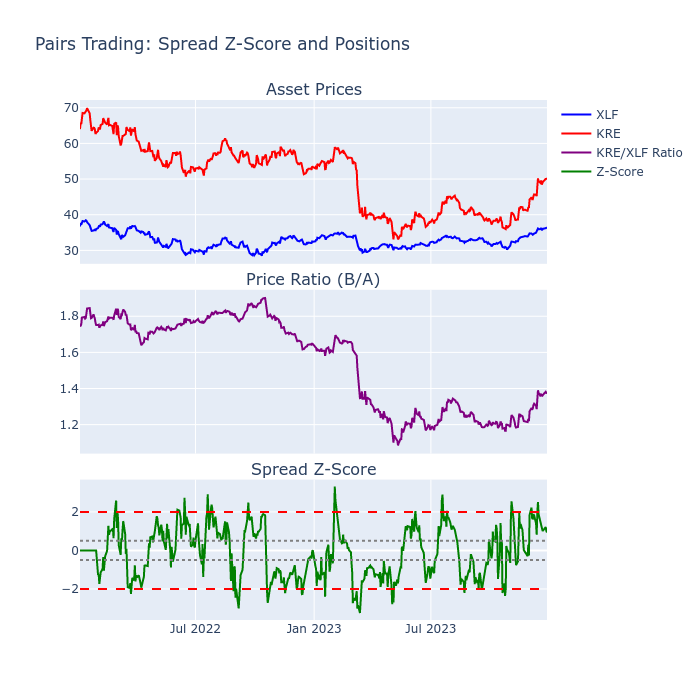

In [18]:
# Add threshold lines and display
if pairs_strategy.zscore_history:
    fig.add_hline(y=2.0, line_dash="dash", line_color="red", row=3, col=1)
    fig.add_hline(y=-2.0, line_dash="dash", line_color="red", row=3, col=1)
    fig.add_hline(y=0.5, line_dash="dot", line_color="gray", row=3, col=1)
    fig.add_hline(y=-0.5, line_dash="dot", line_color="gray", row=3, col=1)

    fig.update_layout(
        height=700, title="Pairs Trading: Spread Z-Score and Positions", showlegend=True
    )
    fig.show()

**Key observation**: The spread signal can be precomputed, but the trade itself
is managed as a stateful object. The strategy opens the lead leg first, sizes
the hedge from the realized lead-leg fill, and unwinds the trade if the hedge
cannot be established quickly. That contingency depends on simulated execution
state, not just on the z-score path.

## Pattern 3: Drawdown Circuit Breaker (Path-Dependent Sizing)

**The idea**: Monitor portfolio drawdown and progressively reduce position sizing
as drawdown deepens. At a critical threshold, halt all new entries entirely.
As the portfolio recovers, gradually resume normal sizing.

**Why a fixed matrix is awkward**: The sizing multiplier at bar N depends on
drawdown through bar N-1, but the realized equity path depends on the sizes used
in prior trades. Equity and exposure co-evolve, so the rule is easiest to write
as a recursive state update rather than as predetermined weights.

### Three Drawdown Zones

| Zone | Drawdown Range | Behavior |
|------|---------------|----------|
| **Normal** | 0% to 3% | Full sizing (multiplier recovers toward 1.0) |
| **Caution** | 3% to 6% | Reduced sizing (linearly interpolated to 0) |
| **Halt** | > 6% | No new entries (multiplier = 0) |

In [19]:
class DrawdownCircuitBreakerStrategy(Strategy):
    """Reduce or halt trading when portfolio drawdown exceeds thresholds."""

    def __init__(
        self,
        signal_column: str = "signal",
        entry_threshold: float = 0.01,
        exit_threshold: float = -0.01,
        base_size: float = 0.10,
        caution_threshold: float = 0.05,
        halt_threshold: float = 0.10,
        reduction_factor: float = 0.5,
        recovery_rate: float = 0.01,
    ):
        self.signal_column = signal_column
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.base_size = base_size
        self.caution_threshold = caution_threshold
        self.halt_threshold = halt_threshold
        self.reduction_factor = reduction_factor
        self.recovery_rate = recovery_rate
        # State
        self.peak_equity: float = 0.0
        self.sizing_multiplier: float = 1.0
        # Track for analysis
        self.multiplier_history: list[float] = []
        self.drawdown_history: list[float] = []

    def on_data(self, timestamp, data, context, broker):
        equity = broker.get_account_value()

        # Update peak and compute drawdown
        if equity > self.peak_equity:
            self.peak_equity = equity
        drawdown = (self.peak_equity - equity) / self.peak_equity if self.peak_equity > 0 else 0.0

        # Update sizing multiplier based on drawdown zone
        if drawdown < self.caution_threshold:
            self.sizing_multiplier = min(1.0, self.sizing_multiplier + self.recovery_rate)
        elif drawdown < self.halt_threshold:
            range_pct = (drawdown - self.caution_threshold) / (
                self.halt_threshold - self.caution_threshold
            )
            self.sizing_multiplier = self.reduction_factor * (1 - range_pct)
        else:
            self.sizing_multiplier = 0.0

        self.multiplier_history.append(self.sizing_multiplier)
        self.drawdown_history.append(drawdown)

        for asset, bar in data.items():
            signals = bar.get("signals", {})
            signal = signals.get(self.signal_column, 0) if signals else 0
            if signal is None:
                signal = 0

            price = bar.get("close", 0)
            if price <= 0:
                continue

            position = broker.get_position(asset)

            if position is None and signal > self.entry_threshold:
                if self.sizing_multiplier <= 0:
                    continue  # Trading halted
                effective_size = self.base_size * self.sizing_multiplier
                shares = (equity * effective_size) / price
                if shares > 0:
                    broker.submit_order(asset, shares)
            elif position is not None and signal < self.exit_threshold:
                broker.close_position(asset)

### Run Circuit Breaker Strategy

We load SPY daily bars from 2019-08 through 2021-07 (500 trading days). The
window covers calm late-2019, the February–March 2020 COVID crash (peak-to-
trough drawdown around 33% in five weeks), and the subsequent recovery into
2021. An alternating entry/exit signal forces the strategy to consider re-
entry while the equity path is still impaired, which is exactly when the
circuit breaker must override the signal.

In [20]:
crash_prices = _load_single_window(symbol="SPY", start="2019-08-01", n_bars=N_BARS)
crash_signals = make_signals(crash_prices, signal_fn="alternating", lookback=12)
CRASH_SYMBOL = "SPY"

# Circuit breaker strategy
cb_strategy = DrawdownCircuitBreakerStrategy(
    entry_threshold=0.0,
    exit_threshold=0.0,
    base_size=0.30,
    caution_threshold=0.03,
    halt_threshold=0.06,
    reduction_factor=0.5,
    recovery_rate=0.02,
)

feed = DataFeed(prices_df=crash_prices, signals_df=crash_signals)
engine = Engine(feed=feed, strategy=cb_strategy, config=config)
cb_result = engine.run()

# Unprotected baseline (same signals, no circuit breaker)
unprotected = FixedSizeStrategy(size=0.30, entry_threshold=0.0, exit_threshold=0.0)
feed_base = DataFeed(prices_df=crash_prices, signals_df=crash_signals)
engine_base = Engine(feed=feed_base, strategy=unprotected, config=config)
base_result = engine_base.run()

cbm = cb_result.metrics
bm = base_result.metrics

**Drawdown circuit breaker vs unprotected baseline** (same signals, sizing rule
differs once the protected strategy hits the caution / halt thresholds):

In [21]:
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "with_breaker": [
            float(cbm["total_return_pct"]),
            float(cbm["sharpe"]),
            float(cbm["max_drawdown_pct"]),
            float(cbm["num_trades"]),
        ],
        "unprotected": [
            float(bm["total_return_pct"]),
            float(bm["sharpe"]),
            float(bm["max_drawdown_pct"]),
            float(bm["num_trades"]),
        ],
    }
)

metric,with_breaker,unprotected
str,f64,f64
"""Total return (%)""",-2.410218,8.520562
"""Sharpe ratio""",-0.246254,0.740018
"""Max drawdown (%)""",7.146291,7.146291
"""Total trades""",7.0,21.0


The circuit breaker cuts the number of trades by roughly two-thirds compared
to the unprotected baseline because the sizing multiplier drops to zero during
the February–March 2020 drawdown and refuses to re-enter while drawdown is
still beyond the halt threshold. Maximum drawdown is similar across the two
strategies in this run: the first crash leg occurs while a position is already
open and the breaker only governs *new* entries, so the realized peak-to-trough
loss reflects the position carried in. The visible cost is the foregone
upside — the protected strategy sits in cash through the most violent part of
the recovery while the unprotected baseline keeps cycling positions on every
signal flip.

### Visualize Circuit Breaker Behavior

The key visualization: drawdown zones and the resulting sizing multiplier.

In [22]:
# Prepare circuit breaker visualization data and equity traces
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    dates = (
        crash_prices.filter(pl.col("symbol") == CRASH_SYMBOL)
        .sort("timestamp")["timestamp"]
        .to_list()
    )
    n = min(len(dates), len(cb_strategy.multiplier_history))

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.35, 0.35, 0.30],
        subplot_titles=["Portfolio Equity", "Drawdown (%)", "Sizing Multiplier"],
    )

    eq = cb_result.to_equity_dataframe()
    fig.add_trace(
        go.Scatter(
            x=eq["timestamp"].to_list(),
            y=eq["equity"].to_list(),
            name="Equity (Protected)",
            line=dict(color="blue"),
        ),
        row=1,
        col=1,
    )

    eq_base = base_result.to_equity_dataframe()
    fig.add_trace(
        go.Scatter(
            x=eq_base["timestamp"].to_list(),
            y=eq_base["equity"].to_list(),
            name="Equity (Unprotected)",
            line=dict(color="gray", dash="dash"),
        ),
        row=1,
        col=1,
    )

In [23]:
# Add drawdown and sizing multiplier traces
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    dd_pct = [d * 100 for d in cb_strategy.drawdown_history[:n]]
    fig.add_trace(
        go.Scatter(x=dates[:n], y=dd_pct, name="Drawdown", fill="tozeroy", line=dict(color="red")),
        row=2,
        col=1,
    )
    fig.add_hline(
        y=3.0, line_dash="dash", line_color="orange", annotation_text="Caution (3%)", row=2, col=1
    )
    fig.add_hline(
        y=6.0, line_dash="dash", line_color="red", annotation_text="Halt (6%)", row=2, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=dates[:n],
            y=cb_strategy.multiplier_history[:n],
            name="Sizing Multiplier",
            line=dict(color="green"),
        ),
        row=3,
        col=1,
    )

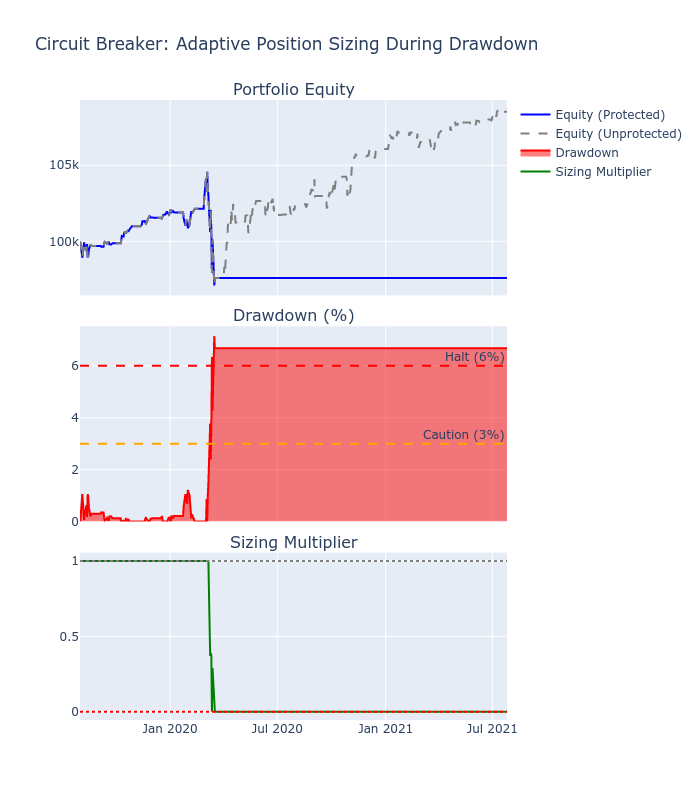

In [24]:
# Add threshold reference lines and display
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    fig.add_hline(y=0, line_dash="dot", line_color="red", row=3, col=1)
    fig.add_hline(y=1, line_dash="dot", line_color="gray", row=3, col=1)

    fig.update_layout(height=800, title="Circuit Breaker: Adaptive Position Sizing During Drawdown")
    fig.show()

**Key observation**: In this run, drawdown crosses the caution threshold, the
sizing multiplier shrinks, and severe losses halt new entries entirely. The
protected strategy finishes with substantially fewer trades than the
fixed-size baseline because the halt is binding for much of the recovery
window. Whether that translates into a lower realized drawdown depends on
the timing of the first crash leg relative to the prior position — and it
does not in this run, since the position was already open when COVID hit.

The point is not that a circuit breaker always improves return. The point is
that future actions depend on realized portfolio state, so the strategy is most
naturally represented as a sequential recursion.

## Summary: When Sequential State Helps

| Pattern | Static array form | Sequential engine | Why? |
|---------|-------------------|-------------------|------|
| Buy on signal, sell on signal | Straightforward | Also works | Decisions depend only on observable data |
| Equal-weight rebalancing | Straightforward | Also works | Target weights are known once the protocol is fixed |
| Position size adapts to realized P&L | Recursive and awkward | Natural fit | Sizing depends on prior realized outcomes |
| Cross-asset capital coordination | Possible, but bookkeeping-heavy | Natural fit | Fills, cash, and margin couple the legs |
| Equity-path-dependent behavior | Recursive and awkward | Natural fit | Equity and sizing co-evolve |
| Reactive order management | Not a fixed matrix | Natural fit | Fills create new contingent orders |
| Pyramiding (conditional entries) | Not a fixed matrix | Natural fit | Entry N depends on prior entries |

**Rule of thumb**: If the full trading protocol can be precomputed as aligned
arrays, use the array-based path. If later actions depend on mutable portfolio
state, explicit sequential simulation is usually clearer and safer.

## Additional Patterns

The library's `examples/stateful_strategies.py` includes two more patterns not
shown here:

- **Pyramiding**: Add to winners based on unrealized P&L thresholds
- **Grid Trading**: Reactive limit order management where each fill triggers
  new orders at adjacent price levels

See the [Stateful Strategies user guide](https://github.com/stefan-jansen/ml4t-backtest/docs/user-guide/stateful-strategies.md)
for all five patterns with code, explanations, and testing guidance.

## Key Takeaways

1. **Array-based backtests are fast because they operate on precomputed arrays**
   and broadcast naturally across parameter grids, but they can consume
   substantial memory when the state space grows.

2. **The important question is not "vectorized or event-driven?" in the
   abstract**. The real question is whether the trading protocol can be fixed
   before execution starts or whether later actions depend on evolving state.

3. **Sequential simulation is often the more natural description of trading**.
   It preserves the loop of observing, updating state, acting, and processing
   outcomes instead of hiding those transitions inside array alignment.

4. **Sequential simulation becomes valuable when fills, realized P&L, equity,**
   or cross-asset coordination feed back into future decisions.

5. **These examples are modeling patterns, not universal library limits**.
   The point is to make state dependence visible and inspectable.

**Next**: Chapter 19 applies these patterns in production risk management.
**Book**: Section 16.3 explains the speed-fidelity spectrum and why
stateful strategies are most naturally expressed as event-driven simulation.